# Hotel Booking Dataset

**What is the problem?**
Hotels face high booking cancellation rates, which lead to revenue loss and uncertainty in room occupancy.

**Why is this problem important?**
Cancellations affect hotel revenue, staffing, resource planning, and pricing strategies. Predicting cancellations helps hotels manage bookings more effectively.

**What is the input of the system?**
The system uses historical booking data such as booking details, customer information, financial data, and distribution channel information to predict cancellations.


# 1) Loading Dataset

In [151]:
import pandas as pd #for dataset
import matplotlib.pyplot as plt #for visualization
import seaborn as sns #for visualization
import numpy as np #for numerical operations

In [152]:
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [153]:
df.info()
#children float64 into int64, agent float64 into int64, company float64 into int64,
# #is_repeated_guest int64 into bool, is_canceled int64 into bool,is_repeated_guest int64 into bool, reservation_status_date object
df.isnull().sum()
#columns with missing values: country, agent, company, children


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

## 2) Data Cleaning and Preprocessing

In [154]:
#Fill missing values so algorithms can work with the data and to avoid losing data by dropping rows with missing values
df['country'].fillna('Unknown', inplace=True)
df['agent'].fillna(0, inplace=True) #ID of agent that made the booking, 0 means booking was made by the customer directly
df['company'].fillna(0, inplace=True) #ID of company that made the booking, 0 means no company involved
df['children'].fillna(0, inplace=True) 

#Change data types so they are more appropriate for the data and to save memory
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)
df['company'] = df['company'].astype(int)
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df.info()
df.isnull().sum()
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119390 non-null  int64  

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [155]:
# Summary statistics for numerical columns
print("Numerical Data Summary")
display(df.describe().T)
#adr has a high standard deviation and a max value of 5400, which is much higher than the mean of 100. 
#This suggests that there are some outliers in the adr column that may need to be investigated further.

# Summary statistics for categorical & boolean columns
print("Categorical Data Summary")
display(df.describe(include=['object', 'bool']).T)


Numerical Data Summary


,count,mean,min,25%,50%,75%,max,std
is_canceled,119390.0,0.370416,0.0,0.0,0.0,1.0,1.0,0.482918
lead_time,119390.0,104.011416,0.0,18.0,69.0,160.0,737.0,106.863097
arrival_date_year,119390.0,2016.156554,2015.0,2016.0,2016.0,2017.0,2017.0,0.707476
arrival_date_week_number,119390.0,27.165173,1.0,16.0,28.0,38.0,53.0,13.605138
arrival_date_day_of_month,119390.0,15.798241,1.0,8.0,16.0,23.0,31.0,8.780829
stays_in_weekend_nights,119390.0,0.927599,0.0,0.0,1.0,2.0,19.0,0.998613
stays_in_week_nights,119390.0,2.500302,0.0,1.0,2.0,3.0,50.0,1.908286
adults,119390.0,1.856403,0.0,2.0,2.0,2.0,55.0,0.579261
children,119390.0,0.103886,0.0,0.0,0.0,0.0,10.0,0.398555
babies,119390.0,0.007949,0.0,0.0,0.0,0.0,10.0,0.097436


Categorical Data Summary


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,119390,178,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


## Outliers and invalid data
## I) Handling Outlier

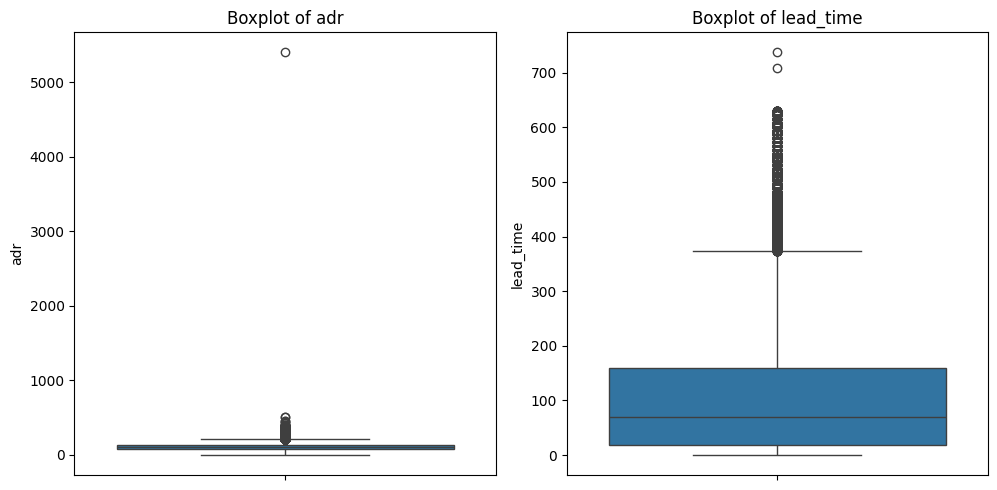

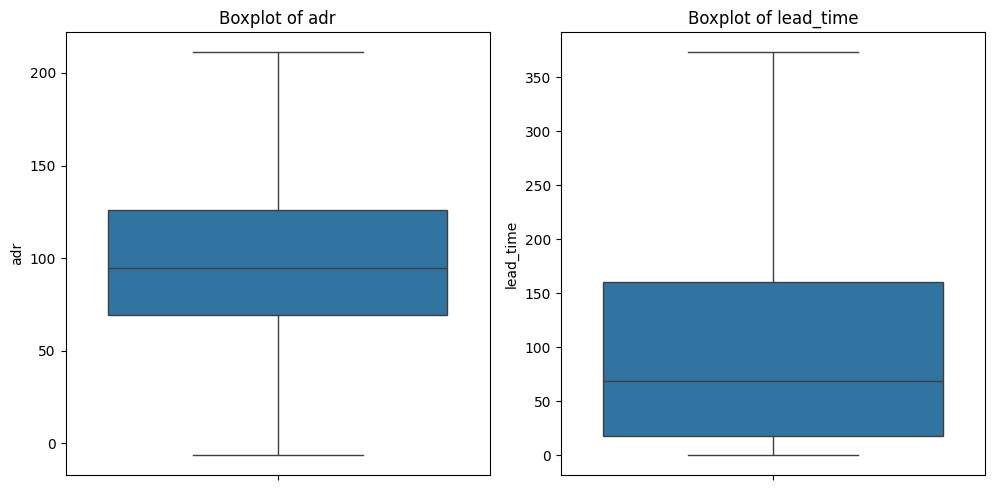

In [156]:
#Outliers were detected using the Interquartile Range (IQR) method:
#such as ADR, lead_time. These features had values that were significantly higher than the rest of the data, indicating potential outliers. 
# To address this, we applied capping to these features using the IQR method, 
# which helps to reduce the influence of extreme values while preserving the overall distribution of the data.

features_to_check = ['adr', 'lead_time']
plt.figure(figsize=(15, 5))
for i, feature in enumerate(features_to_check, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

def cap_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    dataframe[column] = np.where(dataframe[column] > upper_bound, upper_bound,
    np.where(dataframe[column] < lower_bound, lower_bound, dataframe[column]))
    return dataframe

for feature in features_to_check:
    df = cap_outliers_iqr(df, feature)
    
    
plt.figure(figsize=(15, 5))
for i, feature in enumerate(features_to_check, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()


## II) Handling invalid data

In [157]:
print(df['adr'].describe())
#adr has negative values
print((df['adr'] < 0).sum()) 
df = df[df['adr'] >= 0]
df['adr'].describe()

count    119390.000000
mean        100.659305
std          44.688946
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max         211.065000
Name: adr, dtype: float64
1


count    119389.000000
mean        100.660201
std          44.688059
min           0.000000
25%          69.290000
50%          94.590000
75%         126.000000
max         211.065000
Name: adr, dtype: float64

## III) Summary Statistics

In [158]:
#the distribution of the target variable 'is_canceled' is imbalanced, with a higher proportion of non-canceled bookings compared to canceled ones.

df['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.629581
1    0.370419
Name: proportion, dtype: float64

## 1. Summary Statistics for Key Numerical Variables

In [159]:
# Measures of Central Tendency & Dispersion for key numerical columns
key_num_cols = ['lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights',
                'adults', 'children', 'babies', 'booking_changes',
                'days_in_waiting_list', 'total_of_special_requests']

stats = df[key_num_cols].agg(['mean', 'median', 'std', 'var', 'min', 'max', 'skew']).T
stats.columns = ['Mean', 'Median', 'Std Dev', 'Variance', 'Min', 'Max', 'Skewness']
stats

,Mean,Median,Std Dev,Variance,Min,Max,Skewness
lead_time,102.228379,69.00,101.159002,10233.143607,0.0,373.000,1.054711
adr,100.660201,94.59,44.688059,1997.022634,0.0,211.065,0.545709
stays_in_weekend_nights,0.927573,1.00,0.998578,0.997158,0.0,19.000,1.380038
stays_in_week_nights,2.500272,2.00,1.908267,3.641482,0.0,50.000,2.862353
adults,1.856402,2.00,0.579263,0.335546,0.0,55.000,18.317748
children,0.103887,0.00,0.398557,0.158848,0.0,10.000,4.112650
babies,0.007949,0.00,0.097437,0.009494,0.0,10.000,24.646442
booking_changes,0.221109,0.00,0.652288,0.425480,0.0,21.000,6.000704
days_in_waiting_list,2.321169,0.00,17.594793,309.576751,0.0,391.000,11.944303
total_of_special_requests,0.571368,0.00,0.792800,0.628532,0.0,5.000,1.349178


## 2. Mode for Key Variables

In [160]:
# Mode for numerical and categorical columns
print(' Mode of Key Numerical Columns ')
for col in key_num_cols:
    print(f'{col}: {df[col].mode()[0]}')

print('\nMode of Key Categorical Columns')
cat_cols = ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
            'distribution_channel', 'deposit_type', 'customer_type', 'reservation_status']
for col in cat_cols:
    print(f'{col}: {df[col].mode()[0]}')

 Mode of Key Numerical Columns 
lead_time: 0.0
adr: 211.065
stays_in_weekend_nights: 0
stays_in_week_nights: 2
adults: 2
children: 0
babies: 0
booking_changes: 0
days_in_waiting_list: 0
total_of_special_requests: 0

Mode of Key Categorical Columns
hotel: City Hotel
arrival_date_month: August
meal: BB
country: PRT
market_segment: Online TA
distribution_channel: TA/TO
deposit_type: No Deposit
customer_type: Transient
reservation_status: Check-Out


## 3. Cancellation Rate

In [161]:
df['deposit_type'].value_counts()
df.groupby('deposit_type')['is_canceled'].mean() * 100

deposit_type
No Deposit    28.377294
Non Refund    99.362446
Refundable    22.222222
Name: is_canceled, dtype: float64

## 4. Categorical Variable Frequency Tables

In [162]:
# Value counts for key categorical variables
for col in cat_cols:
    print({col})
    print(df[col].value_counts())
    print()

{'hotel'}
hotel
City Hotel      79330
Resort Hotel    40059
Name: count, dtype: int64

{'arrival_date_month'}
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9793
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

{'meal'}
meal
BB           92309
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

{'country'}
country
PRT    48590
GBR    12128
FRA    10415
ESP     8568
DEU     7287
       ...  
MRT        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 178, dtype: int64

{'market_segment'}
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19810
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

{'distribution_channel'}
distrib

---
# Data Visualization

## 9. Reservation Status Distribution

This bar chart shows the distribution of reservation statuses in the hotel booking dataset, including categories such as canceled, check-out, and no-show bookings. It highlights how bookings are distributed across final outcomes.

From the chart, we learn which outcome is most common among all reservations. Typically, check-out represents completed stays, while canceled bookings form a significant portion, indicating a notable cancellation rate in the dataset. No-show cases are usually the smallest group. This helps in understanding the overall behavior of bookings and the imbalance between successful and unsuccessful reservations.

This visualization is important because it gives a clear overview of the target structure and shows that cancellation is a major class in the dataset, which is essential for classification modeling and handling class imbalance.


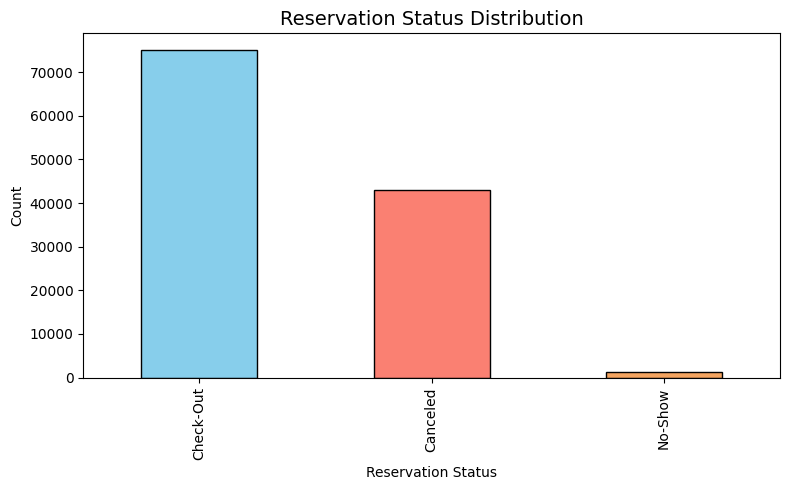

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
rs_counts = df['reservation_status'].value_counts()
rs_counts.plot(kind='bar', color=['skyblue', 'salmon', 'sandybrown'], edgecolor='black')
ax.set_title('Reservation Status Distribution', fontsize=14)
ax.set_xlabel('Reservation Status')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 1. Distribution of Average Daily Rate (ADR)

This histogram shows the distribution of the Average Daily Rate (ADR) for hotel bookings. Most bookings have relatively low to moderate ADR values, while a smaller number of bookings have very high ADR values. The chart reveals that the data is right-skewed because the mean is higher than the median, indicating the presence of some expensive bookings or outliers. This visualization helps in understanding the pricing distribution of hotel bookings and identifying skewness and unusual values in the dataset.


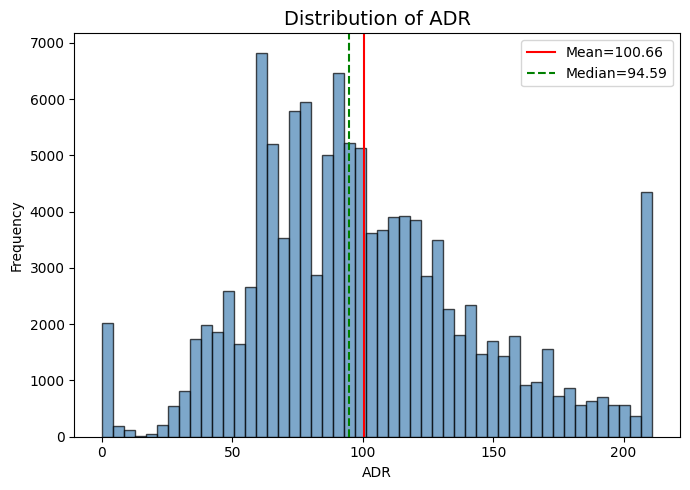

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(df['adr'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Distribution of ADR', fontsize=14)
ax.set_xlabel('ADR')
ax.set_ylabel('Frequency')

ax.axvline(df['adr'].mean(), color='red', linestyle='-', label=f"Mean={df['adr'].mean():.2f}")
ax.axvline(df['adr'].median(), color='green', linestyle='--', label=f"Median={df['adr'].median():.2f}")

ax.legend()

plt.tight_layout()
plt.show()

## 2. Cancellation Rate by Customer Type

What does this chart show? It displays the number of canceled vs. non-canceled bookings for four categories: Transient, Contract, Transient-Party, and Group.
What did you learn from it? "Transient" customers (individual/short-term) make up the bulk of the data and have the highest volume of cancellations. "Transient-Party" customers (individuals associated with a group) cancel less frequently in proportion.
How does it help in understanding the data? It tells the model that the reason for travel (individual vs. part of a contract) is a strong indicator of stability.

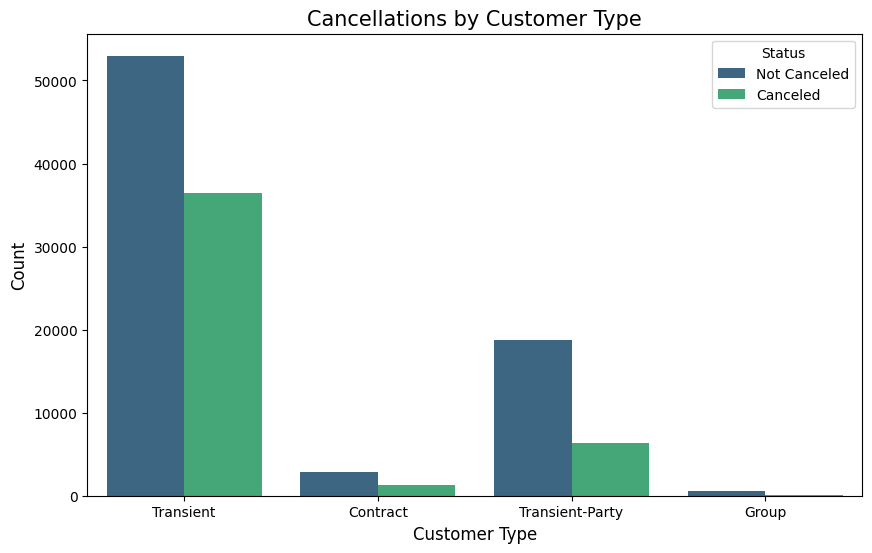

In [197]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='customer_type', hue='is_canceled', palette='viridis')
plt.title('Cancellations by Customer Type', fontsize=15)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Status', labels=['Not Canceled', 'Canceled'])
plt.show()

## 3. Cancellation by Hotel Type

* **What does this chart show?**
  This chart illustrates the cancellation rate for each hotel type, comparing City Hotels with Resort Hotels.

* **What did we learn from it?**
  The analysis shows that City Hotels have a noticeably higher cancellation rate than Resort Hotels. This indicates that bookings in city hotels are more likely to be canceled.

* **How does it help in understanding the data?**
  This visualization highlights the relationship between hotel type and booking cancellation behavior. It suggests that customer behavior differs depending on the type of hotel, making hotel category an important feature for understanding and predicting cancellations.


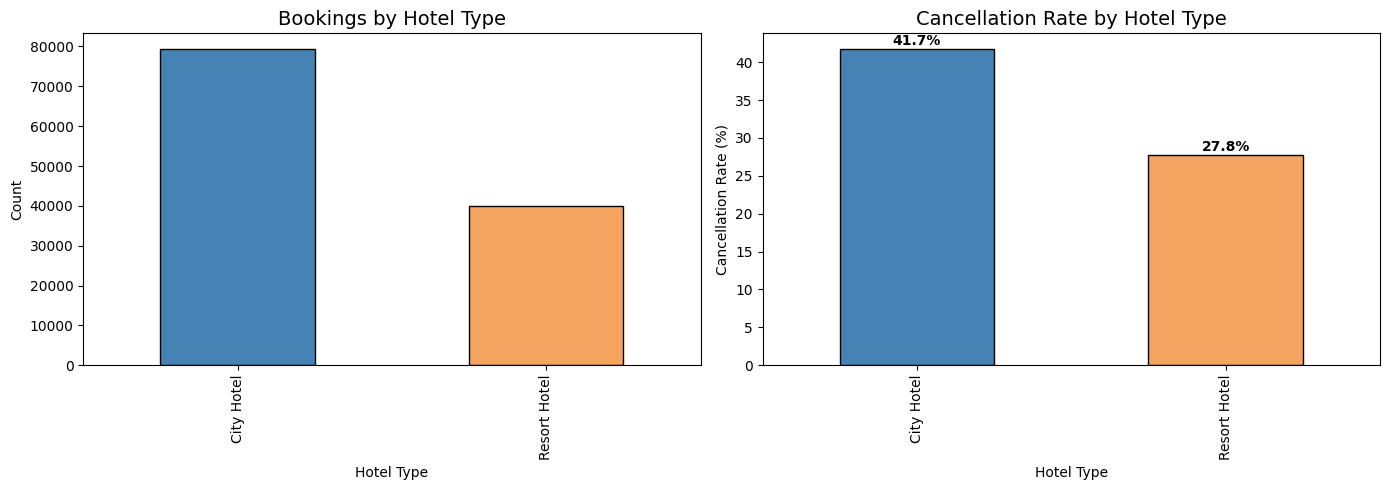

In [166]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hotel_counts = df['hotel'].value_counts()

hotel_counts.plot(
    kind='bar',
    ax=axes[0],
    color=['steelblue', 'sandybrown'],
    edgecolor='black'
)

axes[0].set_title('Bookings by Hotel Type', fontsize=14)
axes[0].set_xlabel('Hotel Type')
axes[0].set_ylabel('Count')
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100

cancel_by_hotel.plot(
    kind='bar',
    ax=axes[1],
    color=['steelblue', 'sandybrown'],
    edgecolor='black'
)

axes[1].set_title('Cancellation Rate by Hotel Type', fontsize=14)
axes[1].set_xlabel('Hotel Type')
axes[1].set_ylabel('Cancellation Rate (%)')
for i, v in enumerate(cancel_by_hotel):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Monthly Booking Trends

-What does this chart show?
 bar chart showing the total number of bookings for each month from January to December.
-What did you learn from it?
We learned that there is clear seasonality in the data. Bookings peak in the summer months (July and August) and drop to their lowest point in the winter (November to January).
-How does it help in understanding the data?
This helps the model understand "time-based" risk. For example, a booking in August might be more stable because it's a primary holiday, whereas a booking in October might be more prone to cancellation. It justifies using the arrival_date_month as a categorical feature.

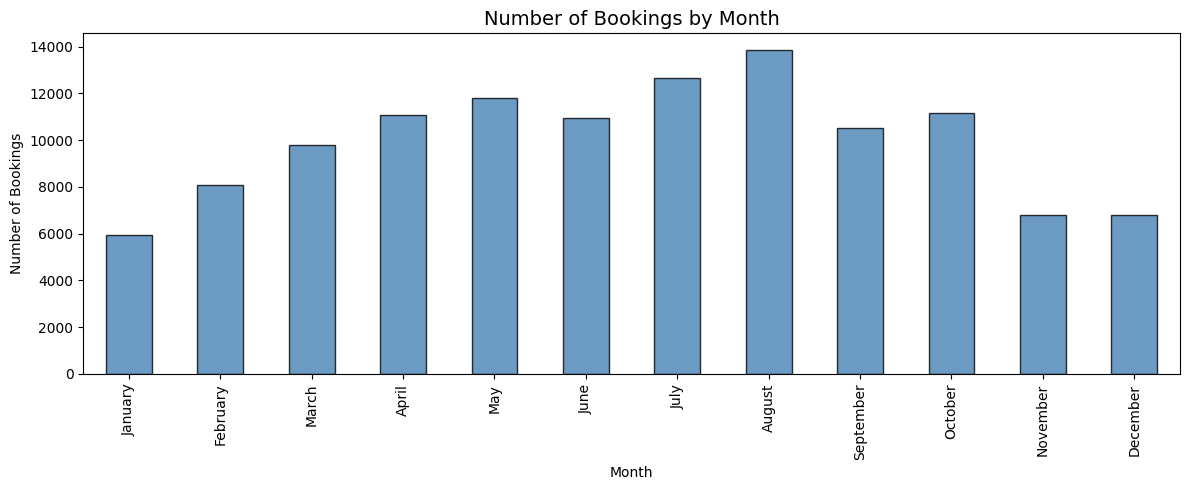

In [167]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = df['arrival_date_month'].value_counts().reindex(month_order)

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
ax.set_title('Number of Bookings by Month', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Bookings')

plt.tight_layout()
plt.show()

## 5. Cancellation Rate by Month

- **What does this chart show?**
This line chart illustrates the average cancellation percentage across different months of the year, sorted chronologically from January to December.
- **What did you learn from it?**
We learned that cancellation rates are highly seasonal. Rates tend to rise during the peak summer months (June to August) and October, while they are significantly lower in the winter months like January and November.
- **How does it help in understanding the data?**
It confirms that "Time of Year" is a major factor in booking stability. For our machine learning model, this justifies why arrival_date_month is a crucial feature, as it captures the seasonal risk associated with holiday periods and peak travel seasons.

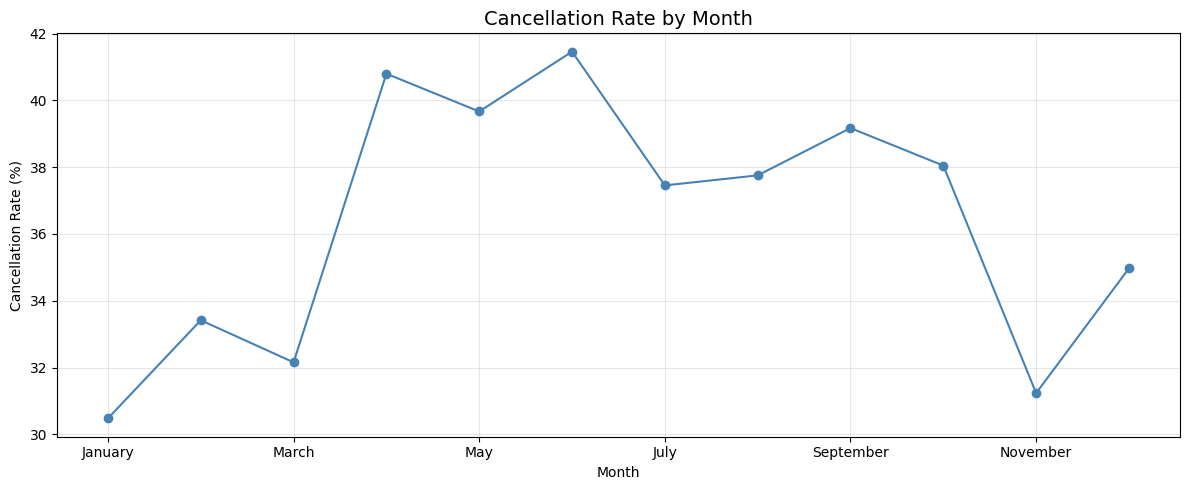

In [168]:
cancel_month = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order) * 100

fig, ax = plt.subplots(figsize=(12, 5))
cancel_month.plot(kind='line', marker='o', color='steelblue' )
ax.set_title('Cancellation Rate by Month', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Cancellation Rate (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Customer Type vs Cancellation Rate (%)

This chart shows the percentage of canceled and non-canceled bookings for each customer type using side-by-side bars. Each customer type is split into two bars: one representing bookings that were not canceled and the other representing bookings that were canceled.

From the visualization, we can compare cancellation behavior across different customer segments. It becomes clear which customer types are more likely to cancel their bookings and which ones tend to complete their reservations. Some customer types show higher cancellation rates, indicating less commitment, while others show more stable booking behavior with higher completion rates.

This chart helps in understanding customer behavior patterns and identifying high-risk segments for cancellations. It is especially useful for decision-making in pricing strategies, cancellation policies, and targeted marketing, since it highlights which customer groups are more reliable versus more likely to cancel.

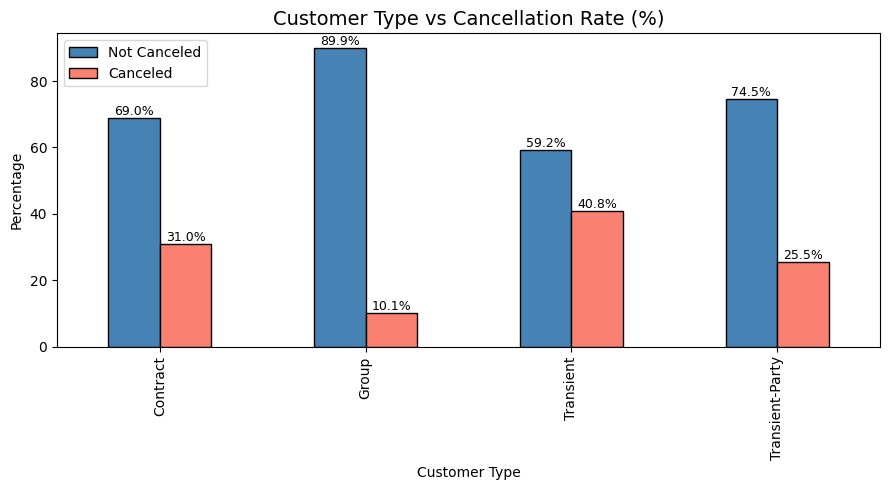

In [210]:
ct_cancel = (
    df.groupby(['customer_type', 'is_canceled'])
    .size()
    .unstack(fill_value=0)
)

# Convert to percentage per customer type
ct_percent = ct_cancel.div(ct_cancel.sum(axis=1), axis=0) * 100

ax = ct_percent.plot(
    kind='bar',
    figsize=(9, 5),
    color=['steelblue', 'salmon'],
    edgecolor='black'
)

ax.set_title('Customer Type vs Cancellation Rate (%)', fontsize=14)
ax.set_xlabel('Customer Type')
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=90)
ax.legend(['Not Canceled', 'Canceled'])

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Country traveling

This chart shows the distribution of hotel bookings across the top 10 countries, split into canceled and non-canceled reservations. Each country is represented by a stacked bar where one part shows completed bookings and the other shows canceled bookings.

From the visualization, we can observe that cancellation behavior varies significantly across countries. Some countries have a high overall number of bookings but also a large portion of cancellations, while others show a more balanced or stable booking pattern with fewer cancellations. This indicates that customer behavior is not uniform globally and depends on the country of origin.

This chart helps in understanding geographic differences in cancellation rates, which can be useful for identifying high-risk markets. It also supports decision-making for targeted policies, pricing strategies, and marketing campaigns based on country-specific booking behavior.


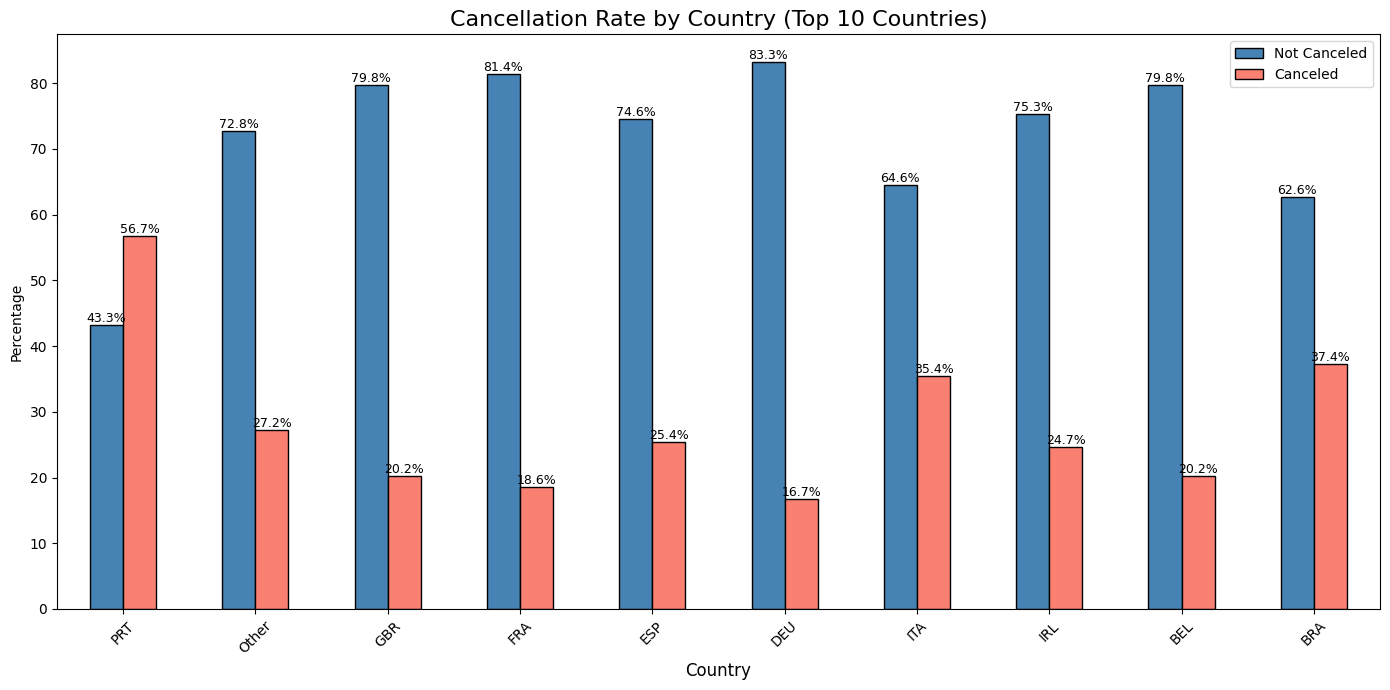

In [216]:
top_countries = df['country'].value_counts().head(10).index

country_cancel = (
    df[df['country'].isin(top_countries)]
    .groupby(['country', 'is_canceled'])
    .size()
    .unstack(fill_value=0)
    .reindex(top_countries)
)

country_percent = country_cancel.div(country_cancel.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))

country_percent.plot(
    kind='bar',
    ax=ax,
    color=['steelblue', 'salmon'],
    edgecolor='black'
)

ax.set_title('Cancellation Rate by Country (Top 10 Countries)', fontsize=16)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=45)
ax.legend(['Not Canceled', 'Canceled'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Repeated Guest vs Cancellation

- What does this chart show?
A comparison of cancellation rates between new guests and repeated guests.
- What did you learn from it?
We learned that repeated guests (loyal customers) have a much lower cancellation rate than first-time bookers.
- How does it help in understanding the data?
It highlights "Customer Loyalty." This tells our model that the is_repeated_guest column is a badge of trust; if this value is 1, the probability of the booking being successful increases significantly.

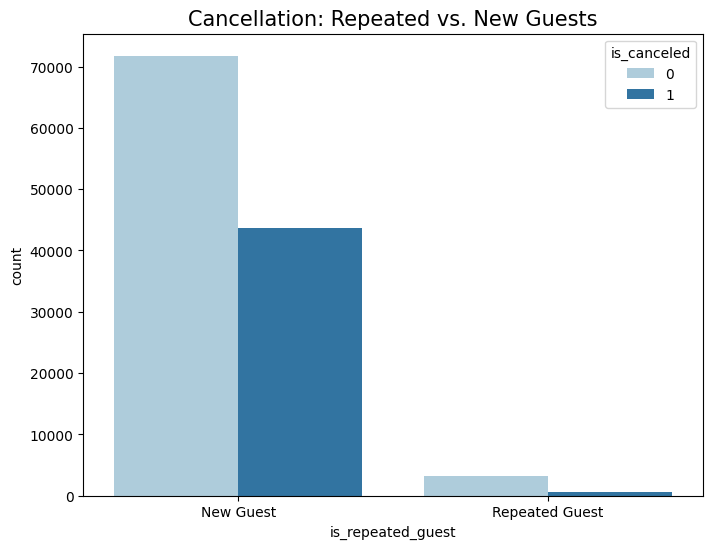

In [220]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='is_repeated_guest', hue='is_canceled', palette='Paired')
plt.title('Cancellation: Repeated vs. New Guests', fontsize=15)
plt.xticks([0, 1], ['New Guest', 'Repeated Guest'])
plt.show()

## 9. Correlation Heatmap

This heatmap shows the correlation between all numerical features in the hotel booking dataset. It visualizes how strongly variables are related to each other, with values close to 1 or -1 indicating strong positive or negative relationships, and values near 0 indicating weak or no correlation. From this chart, we can identify which features are highly related (such as booking status-related variables) and which ones are mostly independent. This helps in feature selection by highlighting important predictors for modeling and removing redundant or less useful variables.


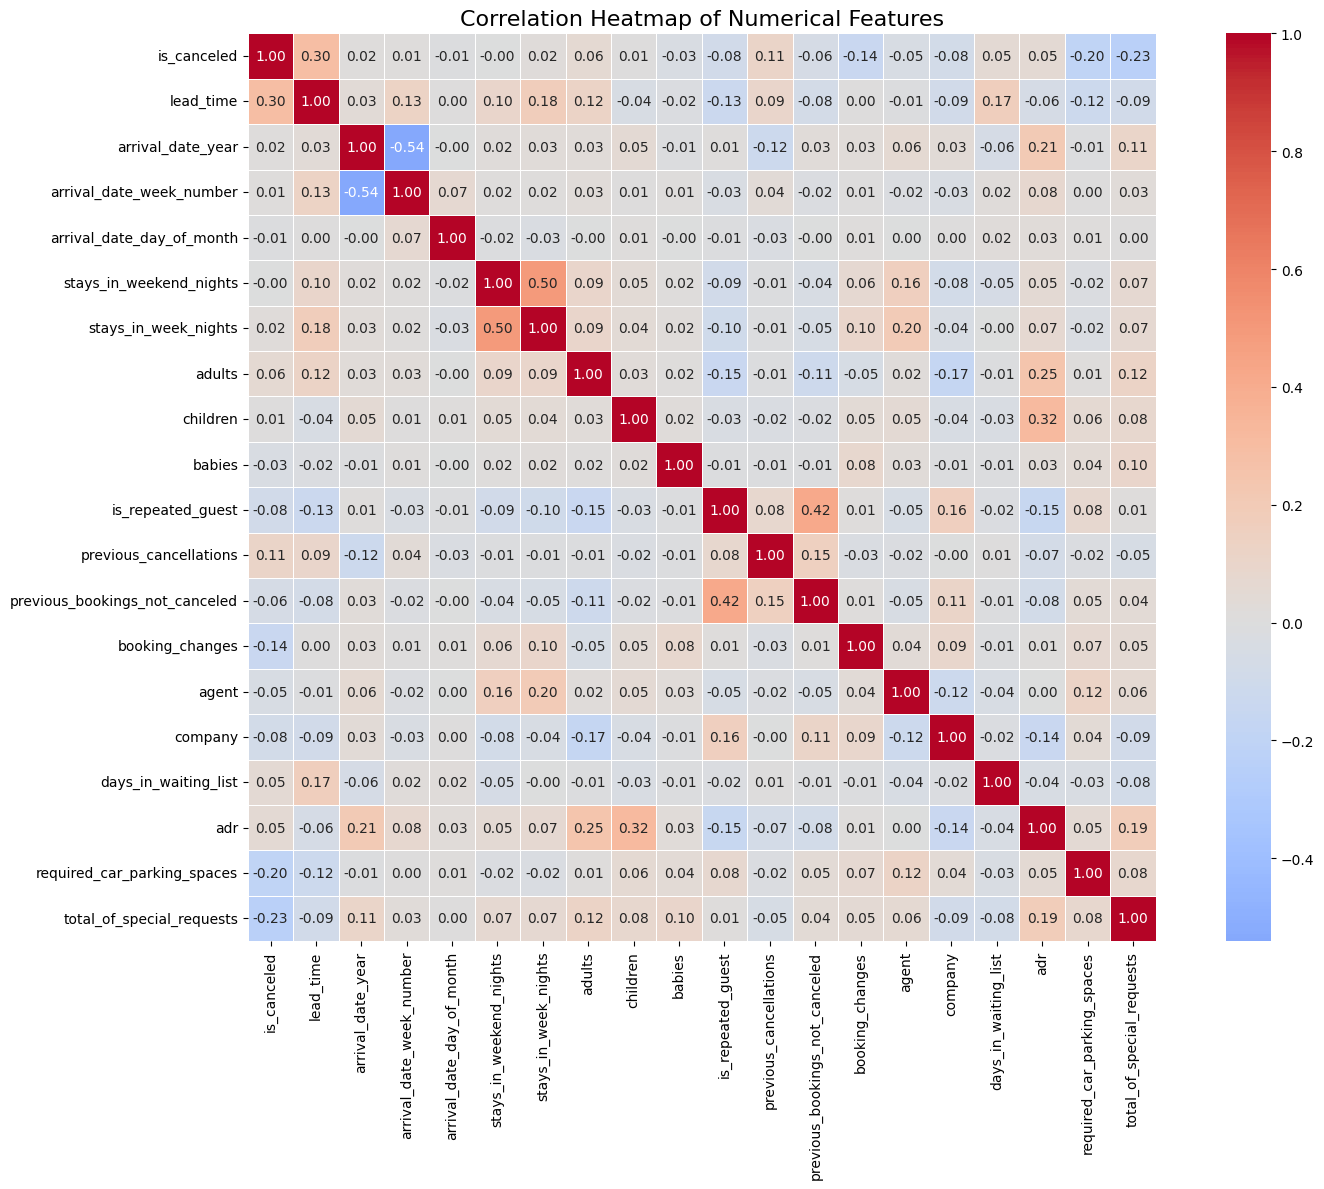

In [176]:
# Correlation heatmap for numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

---
# Dataset Preparation for Machine Learning

                      Feature  Importance
0                   lead_time    0.123664
8                     country    0.115621
46    deposit_type_Non Refund    0.106543
14                        adr    0.075908
16  total_of_special_requests    0.058206
2   arrival_date_day_of_month    0.055600
1    arrival_date_week_number    0.048636
12                      agent    0.046362
10     previous_cancellations    0.037628
18                 total_stay    0.033516


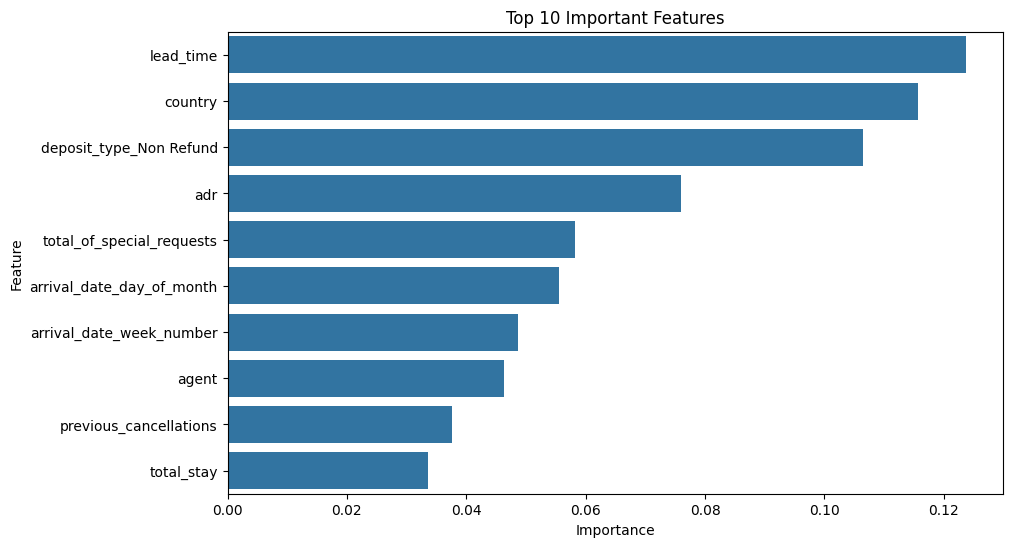

In [ ]:
# Creating a DataFrame to display the importance of each feature in the model.
# y sorting the features based on their importance scores, we can identify which features have the most influence on the model's predictions. 
# The top 10 features are then printed, showing which factors are most critical in determining whether a booking is canceled or not.
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))
#Importance Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.show()

## 1. The required libaries imports

In [179]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

## Feature Engineering

In [180]:
# 1. Total Number of Guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# 2. Total Length of Stay
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# 3. Check for invalid bookings (0 guests)
# Some rows might have 0 adults, children, and babies. These are likely errors.
df = df[df['total_guests'] > 0]

print(f"Dataset shape after creating features: {df.shape}")

Dataset shape after creating features: (119209, 34)


## Feature Selection and Removing Data leakage

In [181]:
# List of columns to drop
# 'reservation_status' is a proxy for the target variable (is_canceled)
# 'reservation_status_date' is recorded after the event
# 'arrival_date_year' might not generalize well to future years
cols_to_drop = ['reservation_status', 'reservation_status_date', 'arrival_date_year', 
                'assigned_room_type', 'booking_changes', 'days_in_waiting_list']

df_model = df.drop(columns=cols_to_drop)

# Also drop columns used to create engineered features if you want to reduce dimensionality
# df_model = df_model.drop(columns=['adults', 'children', 'babies', 'stays_in_weekend_nights', 'stays_in_week_nights'])

df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119209 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119209 non-null  object 
 1   is_canceled                     119209 non-null  int64  
 2   lead_time                       119209 non-null  float64
 3   arrival_date_month              119209 non-null  object 
 4   arrival_date_week_number        119209 non-null  int64  
 5   arrival_date_day_of_month       119209 non-null  int64  
 6   stays_in_weekend_nights         119209 non-null  int64  
 7   stays_in_week_nights            119209 non-null  int64  
 8   adults                          119209 non-null  int64  
 9   children                        119209 non-null  int64  
 10  babies                          119209 non-null  int64  
 11  meal                            119209 non-null  object 
 12  country              

## Handling Categorical Variables (Encoding)

In [182]:
from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding for high-cardinality features (Country)
le = LabelEncoder()
df_model['country'] = le.fit_transform(df_model['country'])

# 2. One-Hot Encoding for other categorical features
# This creates binary columns for each category (e.g., hotel_City Hotel, hotel_Resort Hotel)
categorical_cols = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 
                    'distribution_channel', 'deposit_type', 'customer_type', 'reserved_room_type']

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(f"New shape after One-Hot Encoding: {df_model.shape}")

New shape after One-Hot Encoding: (119209, 60)


## Splitting the Data

In [183]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (95367, 59)
Testing set size: (23842, 59)


## Feature Scaling

In [184]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled.head()

,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,is_repeated_guest,...,customer_type_Transient,customer_type_Transient-Party,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L
0,2.312322,0.799782,0.250611,-0.930995,-0.261726,0.245540,-0.261767,-0.081117,0.929381,-0.180746,...,-1.736603,1.936263,-0.096672,-0.089211,-0.435964,-0.241098,-0.15731,-0.133708,-0.071199,-0.007241
1,1.985965,0.505779,0.364438,1.079744,0.264879,0.245540,-0.261767,-0.081117,0.929381,-0.180746,...,-1.736603,1.936263,-0.096672,-0.089211,-0.435964,-0.241098,-0.15731,-0.133708,-0.071199,-0.007241
2,2.678237,1.608289,-1.684454,-0.930995,0.264879,-1.479934,-0.261767,-0.081117,0.929381,-0.180746,...,0.575837,-0.516459,-0.096672,-0.089211,-0.435964,-0.241098,-0.15731,-0.133708,-0.071199,-0.007241
3,-0.941353,-1.331738,-1.570627,0.074375,0.264879,-1.479934,-0.261767,-0.081117,-0.831674,-0.180746,...,-1.736603,1.936263,-0.096672,-0.089211,-0.435964,-0.241098,-0.15731,-0.133708,-0.071199,-0.007241
4,-0.793010,-1.552240,-1.229145,1.079744,1.844694,0.245540,-0.261767,-0.081117,-0.943134,-0.180746,...,0.575837,-0.516459,-0.096672,-0.089211,-0.435964,-0.241098,-0.15731,-0.133708,-0.071199,-0.007241


## 8. Summary of Prepared Datasets

In [185]:
# Final summary
print('DATASET PREPARATION SUMMARY')
print(f'Target Variable:       is_canceled')
print(f'Number of Features:    {X_train.shape[1]}')
print(f'Total Samples:         {len(X)}')
print(f'Training Samples:      {len(X_train)} (80%)')
print(f'Testing Samples:       {len(X_test)} (20%)')
print(f'Scaling Method:        StandardScaler')
print(f'Encoding Method:       LabelEncoder')
print(f'Stratified Split:      Yes')
print(f'Random State:          42')

print(f'\nFeature names:')
print(X_train.columns.tolist())

DATASET PREPARATION SUMMARY
Target Variable:       is_canceled
Number of Features:    59
Total Samples:         119209
Training Samples:      95367 (80%)
Testing Samples:       23842 (20%)
Scaling Method:        StandardScaler
Encoding Method:       LabelEncoder
Stratified Split:      Yes
Random State:          42

Feature names:
['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'country', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'agent', 'company', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_stay', 'hotel_Resort Hotel', 'arrival_date_month_August', 'arrival_date_month_December', 'arrival_date_month_February', 'arrival_date_month_January', 'arrival_date_month_July', 'arrival_date_month_June', 'arrival_date_month_March', 'arrival_date_month_May', 'arrival_date_month_November', 'arrival_date_month_Oct

## Predictive analytic techniques

## 1. Logistic Regression

In [186]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
# Logistic Regression is a commonly used algorithm for binary classification tasks, predicting whether a hotel booking will be canceled or not.
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8007717473366328
              precision    recall  f1-score   support

           0       0.80      0.92      0.85     15002
           1       0.81      0.60      0.69      8840

    accuracy                           0.80     23842
   macro avg       0.80      0.76      0.77     23842
weighted avg       0.80      0.80      0.79     23842



## 2. Decision Tree

In [187]:
from sklearn.tree import DecisionTreeClassifier
# Decision Tree is a versatile machine learning algorithm that can be used for both classification and regression tasks.
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print( classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.855213488801275
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     15002
           1       0.80      0.81      0.81      8840

    accuracy                           0.86     23842
   macro avg       0.84      0.85      0.85     23842
weighted avg       0.86      0.86      0.86     23842



## 3. Random Forest Classifier

In [188]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive performance and reduce overfitting. 
# It is widely used for classification tasks, including predicting hotel booking cancellations.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8866705813270699
              precision    recall  f1-score   support

           0       0.89      0.94      0.91     15002
           1       0.88      0.80      0.84      8840

    accuracy                           0.89     23842
   macro avg       0.89      0.87      0.88     23842
weighted avg       0.89      0.89      0.89     23842



## 4. Gradient Boosting Classifier

In [189]:
from sklearn.ensemble import GradientBoostingClassifier
# Gradient Boosting is an ensemble learning technique that builds a strong predictive model by combining multiple weak learners, typically decision trees.
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8406593406593407
              precision    recall  f1-score   support

           0       0.84      0.92      0.88     15002
           1       0.84      0.71      0.77      8840

    accuracy                           0.84     23842
   macro avg       0.84      0.81      0.82     23842
weighted avg       0.84      0.84      0.84     23842



## 5.  Model Accuracy Comparison

In [190]:
# Comparisson of the accuracy of the four machine learning models (Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting) on the test set.
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_gb)
]

for m, a in zip(models, accuracy):
    print(f"{m}: {a:.4f}")

Logistic Regression: 0.8008
Decision Tree: 0.8552
Random Forest: 0.8867
Gradient Boosting: 0.8407


# Feature Importance

                      Feature  Importance
0                   lead_time    0.123664
8                     country    0.115621
46    deposit_type_Non Refund    0.106543
14                        adr    0.075908
16  total_of_special_requests    0.058206
2   arrival_date_day_of_month    0.055600
1    arrival_date_week_number    0.048636
12                      agent    0.046362
10     previous_cancellations    0.037628
18                 total_stay    0.033516


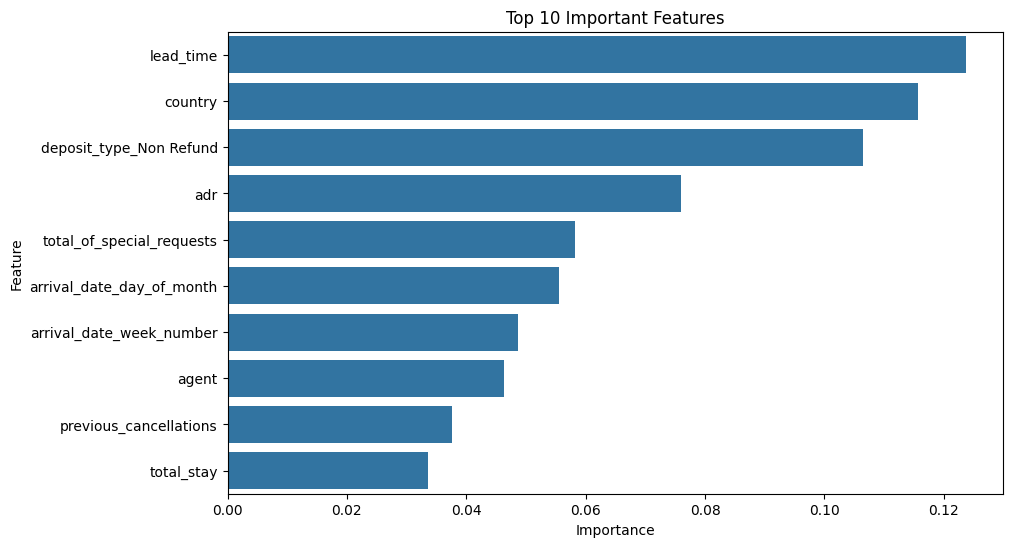

In [191]:
# Creating a DataFrame to display the importance of each feature in the model.
# y sorting the features based on their importance scores, we can identify which features have the most influence on the model's predictions. 
# The top 10 features are then printed, showing which factors are most critical in determining whether a booking is canceled or not.
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))
#Importance Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.show()

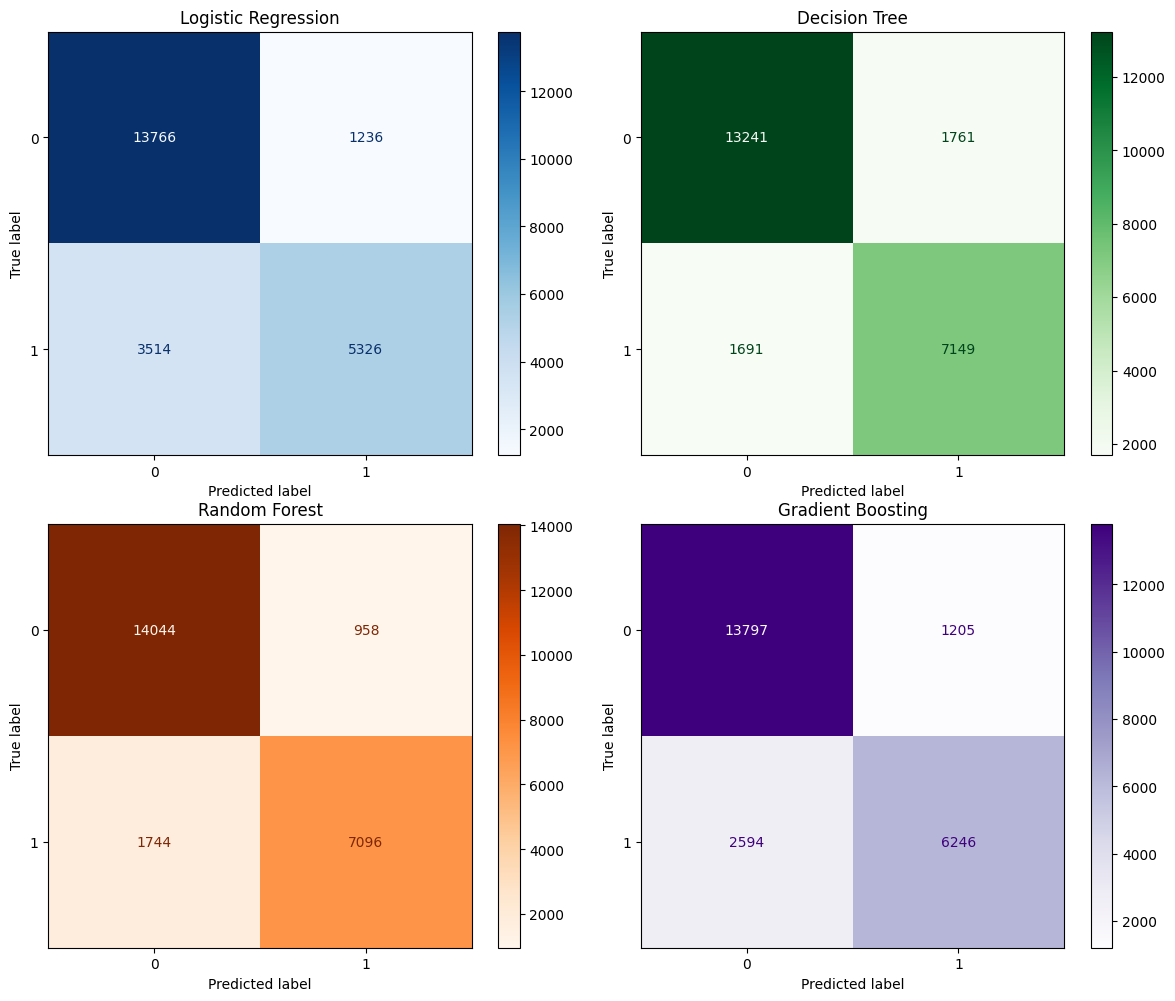

In [192]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    cmap='Blues',
    ax=axes[0, 0]
)
axes[0, 0].set_title("Logistic Regression")

# Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    cmap='Greens',
    ax=axes[0, 1]
)
axes[0, 1].set_title("Decision Tree")

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    cmap='Oranges',
    ax=axes[1, 0]
)
axes[1, 0].set_title("Random Forest")

# Gradient Boosting
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb,
    cmap='Purples',
    ax=axes[1, 1]
)
axes[1, 1].set_title("Gradient Boosting")

plt.tight_layout()
plt.show()

## improved Feature Enigneering & Selection

In [ ]:
top_10_countries = df['country'].value_counts().nlargest(10).index
df['country'] = df['country'].apply(lambda x: x if x in top_10_countries else 'Other')

df['price_per_person'] = df['adr'] / (df['adults'] + df['children'] + 0.1)
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)
cols_to_drop = [
    'agent', 'company', 'arrival_date_year', 
    'assigned_room_type', 'reservation_status', 'reservation_status_date',
    'arrival_date_day_of_month', 'arrival_date_week_number'
]
df_final = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df_final = pd.get_dummies(df_final, drop_first=True, dtype='uint8')

print("Remaining non-numeric columns:", df_final.select_dtypes(include=['object']).columns.tolist())

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_final.drop('is_canceled', axis=1)
y = df_final['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully prepared for models!")

Remaining non-numeric columns: []
Data successfully prepared for models!


## Hyperparameter Tuning

--- FINAL MODEL RESULTS ---
Accuracy: 0.8657
F1-Score: 0.8114

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90     15002
           1       0.85      0.78      0.81      8840

    accuracy                           0.87     23842
   macro avg       0.86      0.85      0.85     23842
weighted avg       0.86      0.87      0.86     23842



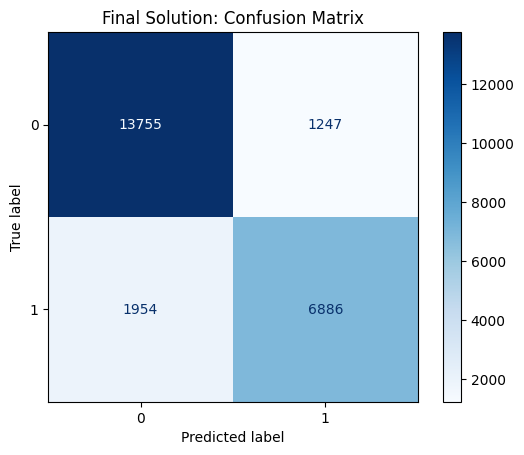

In [194]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Initialize Final Model
# We use XGBoost as it is the industry standard for this type of data
final_model = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.1, 
    max_depth=7, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)

# --- 3. Evaluation ---
print("--- FINAL MODEL RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualize Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Final Solution: Confusion Matrix")
plt.show()